In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

data = pd.read_csv("data.csv", sep=";")
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
data["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [5]:
le = LabelEncoder()
data["Target"] = le.fit_transform(data["Target"])

print("Clases codificadas:", list(le.classes_))

Clases codificadas: ['Dropout', 'Enrolled', 'Graduate']


In [18]:
X = data[[
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)"
]].values

y = data["Target"].values

In [19]:
# 1) Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2) Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
# 3) Modelo KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [21]:
# 4) Modelo Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

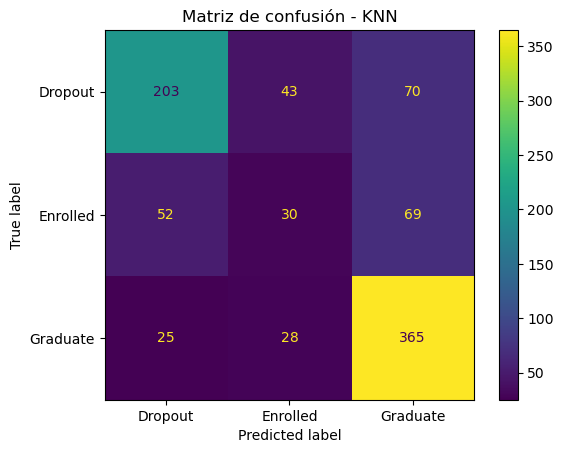

In [22]:
# 5) Matriz de confusión - KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(cm_knn, display_labels=le.classes_)
disp.plot()
plt.title("Matriz de confusión - KNN")
plt.show()

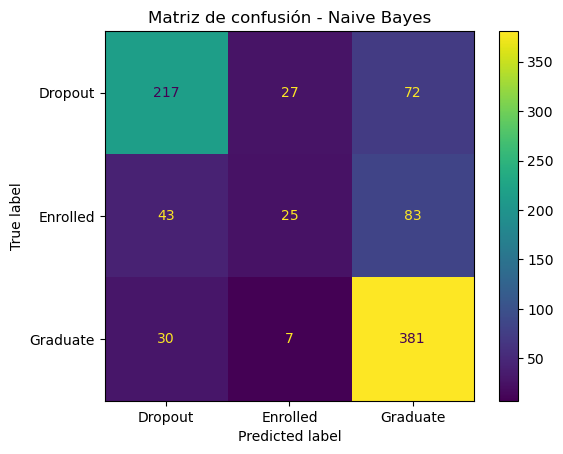

In [23]:
# 6) Matriz de confusión - Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(cm_nb, display_labels=le.classes_)
disp.plot()
plt.title("Matriz de confusión - Naive Bayes")
plt.show()

In [24]:
# 7) ROC-AUC (como Target tiene 3 clases, usamos multi_class="ovr")
proba_knn = knn.predict_proba(X_test)
proba_nb = nb.predict_proba(X_test)

auc_knn = roc_auc_score(y_test, proba_knn, multi_class="ovr")
auc_nb = roc_auc_score(y_test, proba_nb, multi_class="ovr")

print("ROC-AUC KNN:", auc_knn)
print("ROC-AUC Naive Bayes:", auc_nb)

ROC-AUC KNN: 0.7763188499982802
ROC-AUC Naive Bayes: 0.7976468824386744


## Conclusiones
- El modelo Naive Bayes obtuvo mejor ROC-AUC (0.80 vs 0.77), lo que indica que distingue un poco mejor entre las clases.
- En la matriz de confusión se observa que la clase "Enrolled" es la que más se confunde con las otras dos, probablemente porque los estudiantes matriculados comparten características con los que se gradúan o abandonan.
- En general, el modelo Naive Bayes parece más adecuado para este problema porque tuvo mejor desempeño en la métrica ROC-AUC.

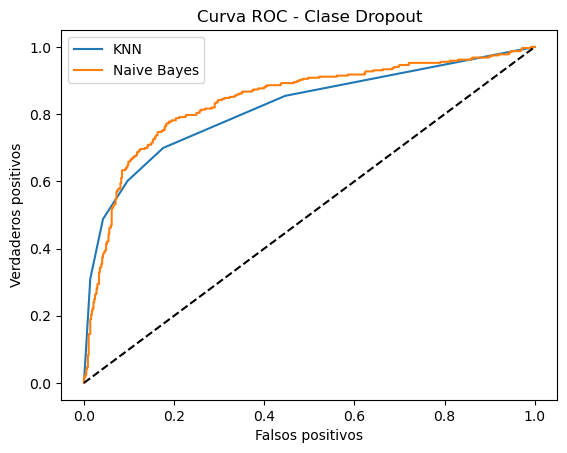

In [25]:
# 8) Curva ROC - Dropout vs el resto (para simplificar, una clase a la vez)
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr, tpr, _ = roc_curve(y_test_bin[:,0], proba_knn[:,0])
plt.plot(fpr, tpr, label="KNN")

fpr, tpr, _ = roc_curve(y_test_bin[:,0], proba_nb[:,0])
plt.plot(fpr, tpr, label="Naive Bayes")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("Falsos positivos")
plt.ylabel("Verdaderos positivos")
plt.title("Curva ROC - Clase Dropout")
plt.legend()
plt.show()

# Uso multi_class="ovr" porque el Target tiene 3 clases (no es binario)
auc_knn = roc_auc_score(y_test, proba_knn, multi_class="ovr")

In [26]:
train_test_split(X, y, test_size=0.2, random_state=42)



[array([[130. ,  35. ,   0. ,   0. ],
        [110. ,  25. ,   3. ,   2. ],
        [123.2,  22. ,   6. ,   6. ],
        ...,
        [112.8,  23. ,   6. ,   6. ],
        [120.4,  19. ,   6. ,   6. ],
        [122.7,  18. ,   5. ,   3. ]], shape=(3539, 4)),
 array([[110. ,  30. ,   0. ,   1. ],
        [119.8,  18. ,   5. ,   6. ],
        [127.4,  18. ,   7. ,   7. ],
        ...,
        [118.2,  20. ,   4. ,   6. ],
        [125.1,  18. ,   6. ,   6. ],
        [124. ,  18. ,   7. ,   7. ]], shape=(885, 4)),
 array([0, 1, 2, ..., 2, 2, 0], shape=(3539,)),
 array([0, 2, 2, 2, 0, 2, 1, 0, 2, 2, 2, 2, 0, 2, 0, 1, 1, 2, 1, 2, 2, 0,
        0, 2, 2, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 2, 2, 2, 1, 0, 0, 2, 0,
        0, 2, 2, 2, 2, 0, 1, 2, 1, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2,
        2, 1, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 2, 0, 0, 2, 0, 2, 1, 2, 2,
        2, 2, 0, 0, 2, 0, 0, 2, 1, 0, 0, 0, 2, 2, 2, 0, 1, 1, 2, 0, 0, 1,
        0, 2, 2, 2, 2, 2, 1, 1, 2, 0, 2, 0, 0, 2, 1, 0, 2, 0, 2

In [27]:
# Se dividió el dataset en 80% para entrenamiento y 20% para prueba (test_size=0.2)

## Preguntas de la profesora

**Porcentaje de train/test:** Se usó 80% de los datos para entrenamiento y 
20% para prueba (test_size=0.2 en train_test_split).

**Técnica usada para mejorar el modelo:** Se aplicó StandardScaler para 
escalar las variables numéricas. Esto es importante porque KNN calcula 
distancias entre puntos, y si una variable tiene valores mucho más grandes 
que otra, dominaría el cálculo sin que eso sea correcto. El escalado pone 
todas las variables en la misma escala para que el modelo las compare de 
forma justa.